In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/311_Service_Requests.csv'

Mounted at /content/drive


##Data Prep

In [ ]:
# @title
"""
# load data
use_cols = [
    "Created Date",
    "Closed Date",
    "Agency",
    "Problem (formerly Complaint Type)",
    "Location Type",
    "Incident Zip",
    "Police Precinct",
    "Borough"
]

df = pd.read_csv(path, usecols=use_cols)
df = df.dropna()

# filter df to top 10
top10 = df['Problem (formerly Complaint Type)'].value_counts().head(10)
df = df[df['Problem (formerly Complaint Type)'].isin(top10.index)]

print(df.info())
df.head()

save_path = "/content/drive/MyDrive/cleaned_311_data.csv"
df.to_csv(save_path, index=False)
"""

In [3]:
save_path = "/content/drive/MyDrive/cleaned_311_data.csv"

df = pd.read_csv(save_path)
df = df.sample(n=50000, random_state=42)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 3427093 to 3517283
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Created Date                       50000 non-null  object 
 1   Closed Date                        50000 non-null  object 
 2   Agency                             50000 non-null  object 
 3   Problem (formerly Complaint Type)  50000 non-null  object 
 4   Location Type                      50000 non-null  object 
 5   Incident Zip                       50000 non-null  float64
 6   Police Precinct                    50000 non-null  object 
 7   Borough                            50000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 3.4+ MB


In [4]:
# rename columns
df = df.rename(columns={
    'Problem (formerly Complaint Type)': 'complaint_type',
    'Created Date': 'created_date',
    'Closed Date': 'closed_date',
    'Location Type': 'location_type',
    'Incident Zip': 'incident_zip',
    'Police Precinct': 'police_precinct',
    'Agency': 'agency',
    'Borough': 'borough'
})

# turn date into datetime
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# calculate resolution hours
df['resolution_hours'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600
print(f"Mean Resolution Time: {df['resolution_hours'].mean()}")

# break created data up into hour, day of week, and month
df['hour'] = df['created_date'].dt.hour
df['day_of_week'] = df['created_date'].dt.dayofweek
df['month'] = df['created_date'].dt.month

df.info()

/tmp/ipykernel_7651/2009907209.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_date'] = pd.to_datetime(df['created_date'])
/tmp/ipykernel_7651/2009907209.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['closed_date'] = pd.to_datetime(df['closed_date'])


Mean Resolution Time: 65.79768636666667
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 3427093 to 3517283
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   created_date      50000 non-null  datetime64[ns]
 1   closed_date       50000 non-null  datetime64[ns]
 2   agency            50000 non-null  object        
 3   complaint_type    50000 non-null  object        
 4   location_type     50000 non-null  object        
 5   incident_zip      50000 non-null  float64       
 6   police_precinct   50000 non-null  object        
 7   borough           50000 non-null  object        
 8   resolution_hours  50000 non-null  float64       
 9   hour              50000 non-null  int32         
 10  day_of_week       50000 non-null  int32         
 11  month             50000 non-null  int32         
dtypes: datetime64[ns](2), float64(2), int32(3), object(5)
memory usage: 4.4+ MB


In [5]:
X = df.drop(columns=['created_date', 'closed_date', 'resolution_hours'])
y = df['resolution_hours']

In [6]:
from sklearn.model_selection import train_test_split

# split train test val + scale numeric data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(36125, 9) (6375, 9) (7500, 9)


##Model Training

In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# encode categorial columns (all)
cat_cols = [
    "agency",
    "complaint_type",
    "location_type",
    "incident_zip",
    "police_precinct",
    "borough"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [8]:
# define model
model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=50,
    random_state=42
)

In [9]:
# pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=50,
        random_state=42
    ))
])

In [10]:
# fit data
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['agency', 'complaint_type',
                                                   'location_type',
                                                   'incident_zip',
                                                   'police_precinct',
                                                   'borough'])])),
                ('model',
                 MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=50,
                              random_state=42))])

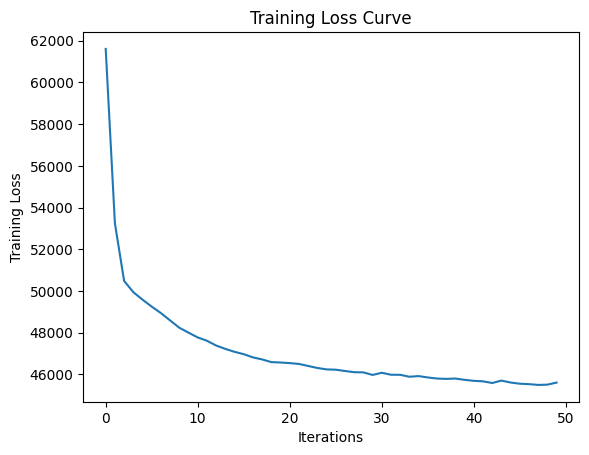

In [11]:
import matplotlib.pyplot as plt

loss_curve = pipeline.named_steps["model"].loss_curve_

plt.plot(loss_curve)
plt.xlabel("Iterations")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

##Model Eval

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = pipeline.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))
print("MSE:", mean_squared_error(y_val, y_pred))

MAE: 62.56270781096876
MSE: 91134.68191478628
